In [19]:
# Instala las bibliotecas necesarias si no las tienes instaladas
!pip install pandas scikit-learn nltk spacy

Defaulting to user installation because normal site-packages is not writeable


# Caso Práctico: Pipeline NLP

En este caso práctico aplicaremos un pipeline de NLP para analizar el sentimiento de los tweets. Para ello, aplicaremos los conceptos dados en las clases 1 y 2.


Descripción del Caso Práctico
El objetivo del caso práctico es:

Preprocesamiento de Texto: Limpiar y normalizar el texto utilizando técnicas como tokenización, eliminación de stopwords, lematización y normalización.
Modelado: Utilizar el algoritmo de clasificación para clasificar las reseñas como positivas o negativas.
Evaluación: Medir el desempeño del modelo con métricas cuantitativas y analizar los resultados para obtener una evaluación cualitativa.



# Importación de librerías

En esta sección, importaremos las librerías necesarias para el desarrollo del caso práctico de NLP.

A continuación, se detallan las librerías que utilizaremos:

- pandas: Permite la manipulación y análisis de datos, esencial para estructurar y preparar nuestros conjuntos de datos.
- nltk: Proporciona un amplio conjunto de herramientas para tareas de preprocesamiento de texto, como tokenización, stemming, y lematización.
- sklearn: Ofrece utilidades para construir modelos de machine learning y realizar evaluaciones.


La librería NLTK es una de las más conocidas en el ámbito del procesamiento de lenguaje natural, proporcionando una amplia gama de funciones para trabajar con texto. Sin embargo, existen otras opciones populares como SpaCy, que a menudo se utilizan para tareas más avanzadas o de alto rendimiento. Se anima a los estudiantes a explorar estas alternativas y elegir la librería que mejor se adapte a sus necesidades.

In [20]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nunoc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Lectura de los datos

In [21]:
df = pd.read_csv("twitter.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


# Exploración de los datos

La etapa de exploración de datos presenta una relevancia algo menor en comparación con otras áreas de la inteligencia artificial siempre es bueno conocer aspectos de los datos.

En este paso, realizaremos un análisis exploratorio básico para obtener información sobre nuestros datos, identificar patrones y detectar anomalías. Empezaremos por cargar el conjunto de datos y examinar sus características principales.

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27481 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
None

Primeras filas del dataset:
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1           

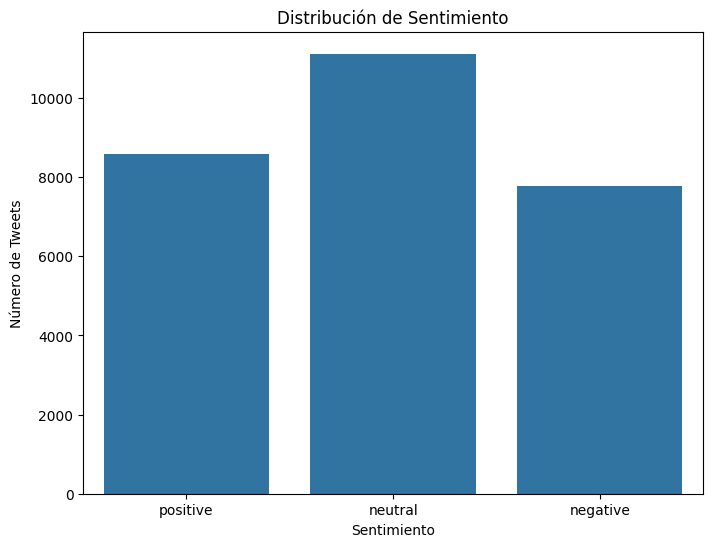

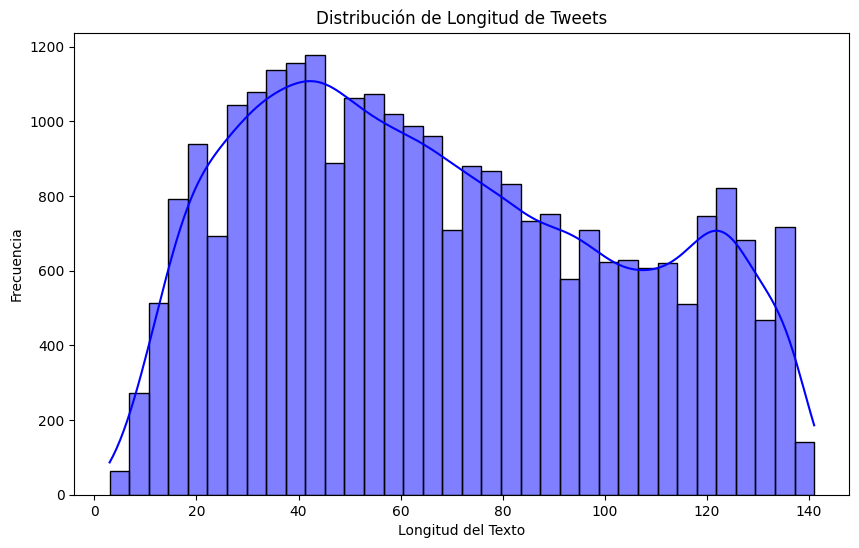

In [22]:
df['text'] = df['text'].astype(str)
print("Información general del dataframe:")
print(df.info())

print("\nPrimeras filas del dataset:")
print(df.head())

print("\nNúmero de valores nulos por columna:")
print(df.isnull().sum())

# Resumen estadístico (para columnas numéricas, si las hubiera)
print("\nDistribución del sentimiento:")
print(df['sentiment'].value_counts())

# Visualización de la distribución del sentimiento
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, order=['positive', 'neutral', 'negative'])
plt.title('Distribución de Sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Número de Tweets')
plt.show()

# Ejemplo de análisis de longitud del texto
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], kde=True, color='blue')
plt.title('Distribución de Longitud de Tweets')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')
plt.show()

# Preprocesamiento

Después de realizar un análisis exploratorio de datos (EDA) para comprender la estructura y las características de nuestro conjunto de datos, el siguiente paso es la etapa de preprocesamiento. El preprocesamiento en un pipeline de NLP es crucial para garantizar que los datos de entrada estén en un formato adecuado para el modelado y análisis.

En esta sección, vamos a realizar varias operaciones clave para preparar el texto, incluyendo:

- Eliminación de caracteres no deseados: Como signos de puntuación y caracteres especiales que no aportan información relevante.
- Conversión a minúsculas: Para evitar inconsistencias debidas a mayúsculas y minúsculas.
- Tokenización: Dividir el texto en palabras o tokens para análisis posteriores.
- Eliminación de palabras irrelevantes (stop words): Palabras comunes que no aportan valor semántico significativo.
- Lematización: Reducción de palabras a sus raíces o formas base, para uniformidad.


Estas etapas son esenciales para mejorar la calidad de los datos de entrada y facilitar la creación de modelos más precisos y efectivos. A continuación, vamos a aplicar estas técnicas a nuestro conjunto de datos para garantizar que esté listo para las siguientes fases del pipeline.

In [23]:
# Preprocesamiento: tokenización, eliminación de stopwords y lematización
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenización
    if not isinstance(text, float):
        tokens = word_tokenize(text.lower())
        # Eliminación de stopwords y lematización
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word.isalnum()]
        return ' '.join(tokens)
    else:
        return ''

df['tweet'] = df['text'].apply(preprocess_text)


for idx, text in enumerate(df['tweet']):
    if idx >= 7:
        break
    print(text)

responded going
sooo sad miss san diego
bos bullying
interview leave alone
son put release already bought
http shameless plugging best ranger forum earth
2am feeding baby fun smile coo


# Modelado

Tras el preprocesamiento del texto, el siguiente paso en nuestro pipeline de NLP es el modelado.

En este caso práctico, emplearemos la técnica de vectorización presentada en clase, TF-IDF (Term Frequency-Inverse Document Frequency), que convierte el texto en una representación numérica basada en la frecuencia de aparición de las palabras, ajustada por la rareza de estas en el corpus. En la clase 3 profundizaremos más sobre esta técnica.

El uso de TF-IDF nos permite capturar información importante sobre las palabras más significativas para el análisis de sentimiento.

Para el modelo de clasificación, utilizaremos un algoritmo de regresión logística, un enfoque popular para problemas de clasificación binaria o multiclase. Antes de entrenar el modelo, debemos tener en cuenta que las clases de nuestro conjunto de datos están desbalanceadas, lo que puede llevar a modelos sesgados o menos efectivos.

Para abordar este desbalanceo, aplicaremos un oversampler de la librería imblearn. Esta técnica genera ejemplos adicionales para la clase minoritaria, equilibrando el conjunto de datos y ayudando a mejorar el rendimiento del modelo.

Con esta información, ahora podemos proceder con la vectorización del texto y el entrenamiento del modelo para realizar el análisis de sentimiento. En la siguiente celda de código, implementaremos estos pasos.

In [24]:
# Balancear el conjunto de datos con sobremuestreo
oversampler = RandomOverSampler(random_state=42)
X, y = df['tweet'], df['sentiment']
X_balanced, y_balanced = oversampler.fit_resample(X.values.reshape(-1, 1), y)

# Separar el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced.flatten(), y_balanced, test_size=0.2, random_state=42)

# Modelado: TF-IDF y Regresión Logística
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(multi_class='ovr', class_weight='balanced')
model.fit(X_train_tfidf, y_train)

C:\Users\nunoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', multi_class='ovr')

# Evaluación

Una vez que el modelo de análisis de sentimiento ha sido entrenado, el siguiente paso es evaluar su rendimiento. La evaluación es crucial para entender la precisión y la eficacia del modelo, y para identificar áreas de mejora.

En esta celda, emplearemos varias métricas comunes para evaluar el rendimiento de nuestro modelo de clasificación basado en regresión logística. A continuación se describe las herramientas que utilizaremos para esta evaluación:

- Matriz de confusión: Proporciona una visualización de las predicciones correctas e incorrectas, permitiendo ver las verdaderas clases positivas y negativas, así como las falsas positivas y negativas.

- Precisión, Recall y F1-Score: Miden diferentes aspectos de la calidad del modelo, como la proporción de verdaderos positivos entre todas las predicciones positivas, la proporción de verdaderos positivos entre todas las clases positivas, y una combinación de precisión y recall, respectivamente.

En esta celda, aplicaremos estas técnicas para evaluar nuestro modelo de análisis de sentimiento y proporcionar una visión completa de su rendimiento. Vamos a dividir el conjunto de datos, hacer predicciones y generar las métricas mencionadas para obtener una evaluación precisa.

Reporte de Clasificación:
              precision    recall  f1-score   support

    negative       0.76      0.73      0.75      2251
     neutral       0.63      0.66      0.64      2173
    positive       0.79      0.77      0.78      2247

    accuracy                           0.72      6671
   macro avg       0.72      0.72      0.72      6671
weighted avg       0.73      0.72      0.72      6671



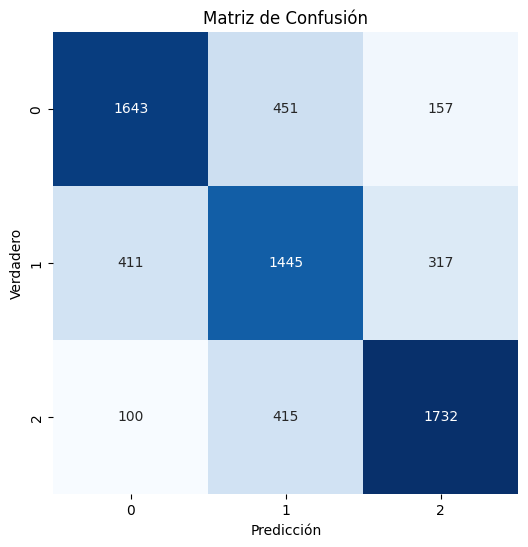

In [25]:
# Evaluación
y_pred = model.predict(X_test_tfidf)

# Métricas de evaluación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.show()


Los resultados del modelo de análisis de sentimiento indican un rendimiento aceptable con una precisión del 73%. La categoría positive obtuvo el mejor f1-score (0.78), mientras que neutral tuvo el rendimiento más bajo (f1-score de 0.64). Aunque el modelo clasifica bien las emociones extremas, puede confundirse con sentimientos más ambiguos. Se puede mejorar el rendimiento, especialmente en la clase neutral, para obtener una mejor precisión y equilibrio general.

# Comentarios Adicionales para realizar el caso práctico

Para aplicar el Pipeline de NLP sobre las reseñas de productos Amazon se recomienda incluir la siguiente ínea de código dentro después de realizar la lectura de datos.

Las reseñas de Amazon vienen rankeadas de 1 a 5. La siguiente línea de código genera 2 clases: negativa y positiva. La categoría negativa se da cuando el rating proporcionado por el usuario es igual o menor que 3 y positiva si es igual o mayor a 4.

In [26]:
df_amazon = pd.read_csv("amazon_reviews.csv")
df_amazon.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [27]:
df_amazon['label'] = df_amazon['overall'].apply(lambda x: 1 if x >= 4 else 0)

# Exploración de los datos

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
 12  label                 4915 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 499.3+ KB
None

Primeras filas del data

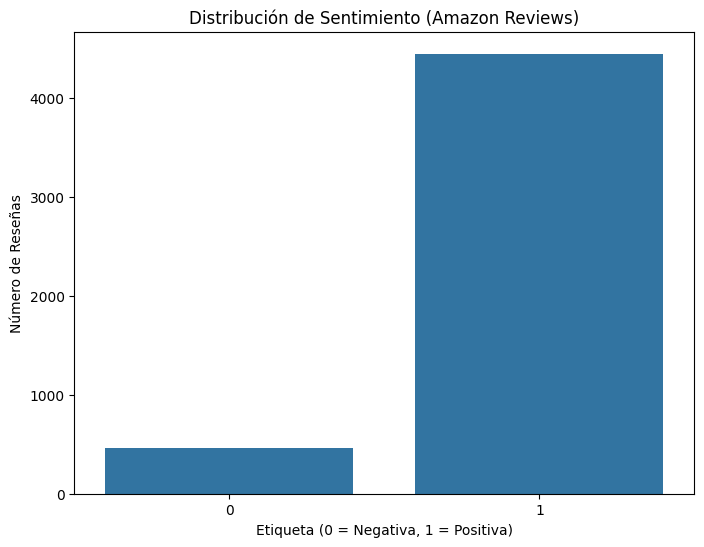

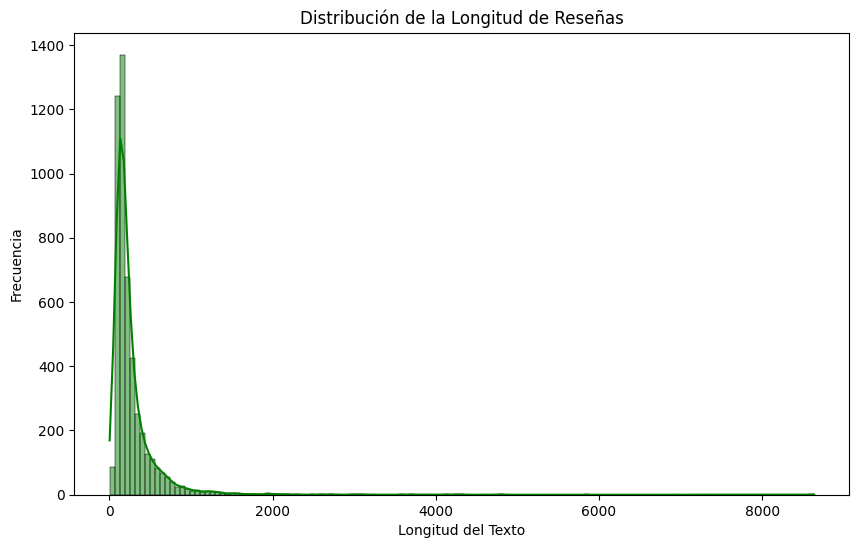

In [28]:
print("Información general del dataframe:")
print(df_amazon.info())

print("\nPrimeras filas del dataset:")
print(df_amazon.head())

print("\nNúmero de valores nulos por columna:")
print(df_amazon.isnull().sum())

print("\nDistribución de reseñas positivas y negativas:")
print(df_amazon['label'].value_counts())

# Visualizar la distribución de las clases
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_amazon)
plt.title('Distribución de Sentimiento (Amazon Reviews)')
plt.xlabel('Etiqueta (0 = Negativa, 1 = Positiva)')
plt.ylabel('Número de Reseñas')
plt.show()

# Calcular la longitud de cada reseña
df_amazon['text_length'] = df_amazon['reviewText'].astype(str).apply(len)

# Visualizar la distribución de la longitud de las reseñas
plt.figure(figsize=(10, 6))
sns.histplot(df_amazon['text_length'], kde=True, color='green')
plt.title('Distribución de la Longitud de Reseñas')
plt.xlabel('Longitud del Texto')
plt.ylabel('Frecuencia')
plt.show()

# Preprocesamiento

In [29]:
# Importar recursos necesarios de NLTK
stop_words = set(stopwords.words('english'))  # Usar stopwords en inglés
lemmatizer = WordNetLemmatizer()

# Definir función para preprocesar el texto
def preprocess_text_amazon(text):
    # Comprobar si el texto no es vacío o nulo
    if not isinstance(text, float):
        # Pasar a minúsculas y tokenizar
        tokens = word_tokenize(text.lower())

        # Eliminar stopwords y palabras con símbolos o números
        tokens = [word for word in tokens if word not in stop_words and word.isalnum()]

        # Lematizar cada palabra
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

        # Unir tokens en un solo string
        return ' '.join(tokens)
    else:
        return ''

# Aplicar la función de preprocesamiento a la columna reviewText
df_amazon['clean_review'] = df_amazon['reviewText'].apply(preprocess_text_amazon)

# Mostrar ejemplos de reseñas ya preprocesadas
for idx, text in enumerate(df_amazon['clean_review']):
    if idx >= 7:
        break
    print(text)
    
# Tratamiento de outliers
# Calcular la longitud de cada reseña
df_amazon['text_length'] = df_amazon['clean_review'].apply(len)

# Filtrar reseñas muy cortas o muy largas
df_amazon = df_amazon[(df_amazon['text_length'] > 20) & (df_amazon['text_length'] < 1000)]

# Verificar el nuevo tamaño del dataset
print("Número de reseñas después de eliminar outliers:", len(df_amazon))

issue
purchased device worked advertised never much phone memory since download lot stuff brainer
work expected sprung higher capacity think made bit cheesier earlier version paint look clean
think worked diff bran 64gb card went south 3 one held pretty well since s3 note3 update month zero issue since transferred s3 note3 note2 card reliable solid cheer
bought retail packaging arrived legit orange envelope english version asian like picture show arrived quickly bought 32 16 retail packaging htc one sv lg optimus card working order probably best price get nice sd card
mini storage anything else supposed purchased add additional storage microsoft surface pro tablet come 64 128 gb supposed sandisk long standing reputation speaks
phone never skip beat file transfer speedy corruption issue memory fade issue would expect sandisk brand great card entrust precious file slightly cheaper piece crap lose everything forgive spending extra couple buck trusted product go good qa
Número de reseñas d

# Modelado

In [30]:
# Importar herramienta para balancear los datos
oversampler = RandomOverSampler(random_state=42)

# Seleccionar las variables X (texto limpio) e y (etiqueta)
X = df_amazon['clean_review']
y = df_amazon['label']

# Balancear los datos para tener misma cantidad de positivas y negativas
X_balanced, y_balanced = oversampler.fit_resample(X.values.reshape(-1, 1), y)

# Separar los datos en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced.flatten(), y_balanced, test_size=0.2, random_state=42)

# Transformar el texto con TF-IDF para vectorizarlo
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Crear modelo de regresión logística para clasificación binaria
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced')

# Evaluación

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       884
           1       0.98      0.93      0.95       870

    accuracy                           0.95      1754
   macro avg       0.95      0.95      0.95      1754
weighted avg       0.95      0.95      0.95      1754



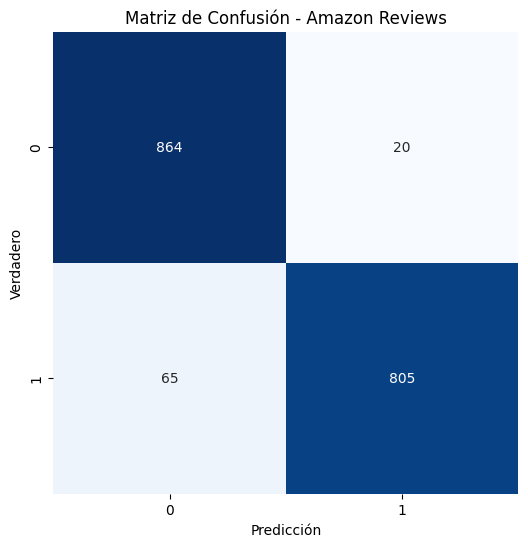

In [31]:
# Predecir etiquetas con el modelo entrenado
y_pred = model.predict(X_test_tfidf)

# Mostrar reporte con precisión, recall y f1-score
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Mostrar matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión - Amazon Reviews')
plt.show()

## Conclusión
A partir del código base utilizado para clasificar sentimientos en tweets, se adaptó el mismo pipeline para analizar reseñas de productos en Amazon. Primero se exploraron los datos y se creó una nueva columna label para convertir la variable overall en una clasificación binaria: 1 para reseñas positivas (≥ 4) y 0 para negativas (< 4).

Se observó un fuerte desbalanceo entre clases (aproximadamente 90% de las reseñas eran positivas), por lo que se aplicó sobremuestreo con RandomOverSampler. Antes de entrenar, se realizó el preprocesamiento del texto: minúsculas, tokenización, eliminación de stopwords, lematización y limpieza general. También se eliminaron outliers según la longitud del texto, conservando solo reseñas entre 20 y 1000 caracteres.

Luego, se vectorizó el texto con TF-IDF y se entrenó un modelo de regresión logística con class_weight='balanced'. El modelo fue evaluado con un conjunto de prueba, alcanzando un 95% de accuracy. El reporte mostró un precision de 0.93 para reseñas negativas y 0.98 para positivas, con valores equilibrados de recall y f1-score. La matriz de confusión confirmó este excelente rendimiento, con pocos errores de clasificación.

### Extra

In [ ]:
import numpy as np

coef = model.coef_[0]
features = vectorizer.get_feature_names_out()
words_weights = list(zip(features, coef))

print("Palabras más asociadas a sentimiento positivo:")
for word, weight in sorted(words_weights, key=lambda x: x[1], reverse=True)[:10]:
    print(f"{word}: {round(weight, 3)}")

print("\nPalabras más asociadas a sentimiento negativo:")
for word, weight in sorted(words_weights, key=lambda x: x[1])[:10]:
    print(f"{word}: {round(weight, 3)}")


Palabras más asociadas a sentimiento positivo:
great: 5.509
fast: 2.873
nice: 2.669
space: 2.628
tablet: 2.609
well: 2.559
perfectly: 2.46
love: 2.456
easy: 2.445
far: 2.427

Palabras más asociadas a sentimiento negativo:
month: -4.934
return: -4.209
card: -4.117
failed: -4.057
tried: -3.782
even: -3.684
died: -3.673
lost: -3.55
started: -3.377
stopped: -3.308
